In [16]:
#Importing Packages required
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("gold_price_data.csv")

In [22]:
#Setting Date as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True) #Having Date convert into Dataframe

In [14]:
# Remove columns that leak target information
leakage_keywords = ['Close', 'Adj', 'close', 'adj', 'price' , 'Price']

safe_columns = [
    col for col in df.columns
    if col not in ['Close'] and not any(key.lower() in col.lower() for key in leakage_keywords)
]

X = df[safe_columns]
y = df['Close']

# Keep numeric only
X = X.select_dtypes(include=[np.number])

# Drop missing values
X = X.dropna()
y = y.loc[X.index]

X.shape

(1718, 59)

In [23]:
#Since we cannot use the particular day's close data for absolute accuracy, let's use the previous day's close data. i.e T-1
X_lagged = X.shift(1)
X_lagged = X_lagged.dropna()

y_lagged = y.loc[X_lagged.index]

print(X_lagged.shape)

(1717, 59)


In [25]:
#Train-Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_lagged,
    y_lagged,
    test_size=0.2,
    shuffle=False
)

In [26]:
#Linear Regression (Model 1)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression
MAE: 0.654888620645535
RMSE: 0.8466864507535147
R²: 0.9665705226725336


In [28]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

In [29]:
#Random Forest (Model2)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest
MAE: 0.6827095902325623
RMSE: 0.8993143779316113
R²: 0.9622855793968608


In [30]:
correlation = X_lagged.corrwith(y_lagged).sort_values(key=abs, ascending=False)

print(correlation.head(10))

High        0.997058
Low         0.996982
Open        0.996540
GDX_Low     0.974766
GDX_High    0.974492
GDX_Open    0.974088
SF_Low      0.945383
SF_Open     0.943346
SF_High     0.942750
EG_low      0.863254
dtype: float64


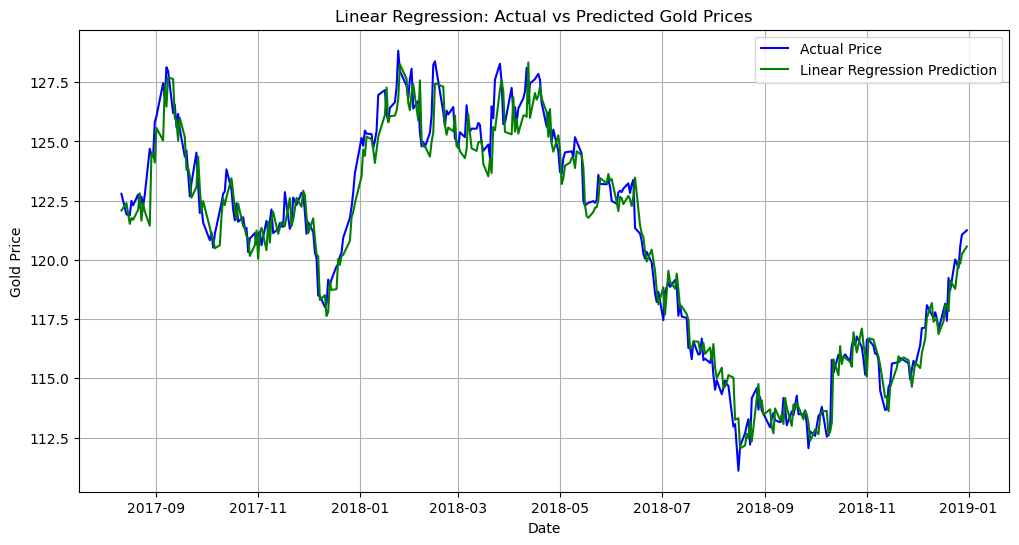

In [31]:
#Plotting of LR
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Price', color='blue')
plt.plot(y_test.index, y_pred_lr, label='Linear Regression Prediction', color='green')

plt.title('Linear Regression: Actual vs Predicted Gold Prices')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()

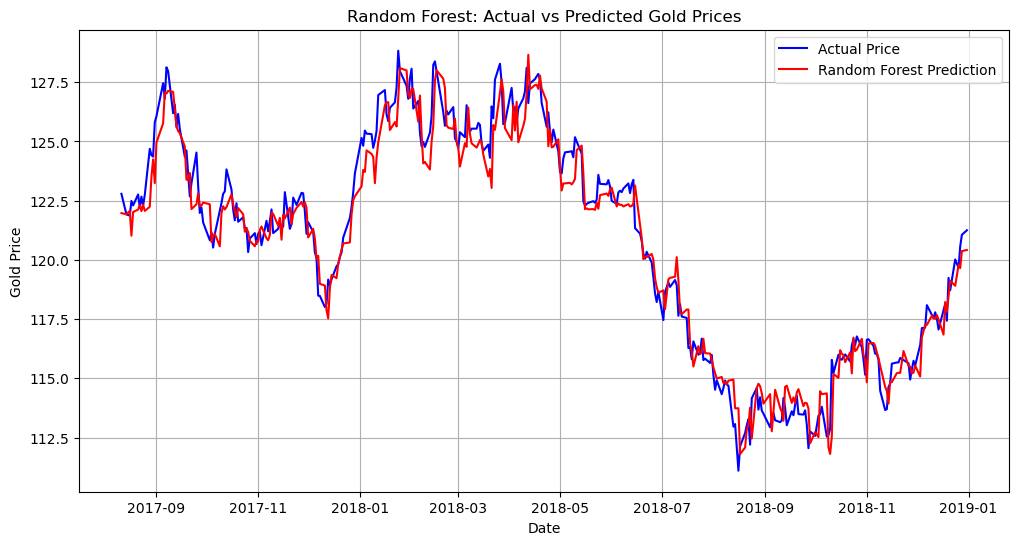

In [32]:
#Plotting of RF
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Price', color='blue')
plt.plot(y_test.index, y_pred_rf, label='Random Forest Prediction', color='red')

plt.title('Random Forest: Actual vs Predicted Gold Prices')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()